# IMA Project

Préembule :
Tout le code ci-dessous a été écrit par Quentin et Colin à l'exception de la fonction ```resoud_quad_fourrier``` fournie par notre enseignant Said Ladjal. L'autocomplétion de code par IA a été utilisé mais jamais pour réaliser des tâches en rapport avec le raisonnement mathématique ou l'implémentation des formules complexes.
Nous avons utilisé le français et l'anglais de manière un peu confuse en fonction des moments et des raisonements à partir des noms de variables dans les papiers.

In [ ]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io

plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
DATA_DIR = Path(__file__).parent.joinpath('..').resolve() / 'assets' if '__file__' in globals() else Path('..') / 'assets'
IMAGE_REF = DATA_DIR / 'image_ref.jpg'
IMAGE_DENOISED_OUT = DATA_DIR / 'image_denoised.jpg'
IMAGE_BLURRED_OUT = DATA_DIR / 'image_blurred.jpg'


## Kernel utilisé pour le gradient (dépendant de la taille de l'image, donc à définir plus tard)
kernel_derivation_x = None
kernel_derivation_y = None

In [ ]:
def denoise_colored_image(noisy_image, h=10, hColor=10, templateWindowSize=7, searchWindowSize=15):
    """Denoise a color image using OpenCV's Non-local Means (fastNlMeansDenoisingColored)."""
    return cv2.fastNlMeansDenoisingColored(noisy_image, None, h, hColor, templateWindowSize, searchWindowSize)

def kernel_vers_grand(k, n, m):
   p = len(k)
   N = (len(k)+1)//2
   M = len(k)-N

   out = np.zeros((n, m))
   out[0:N,0:N] =k[M:p,M:p]
   out[-M:,-M:] =k[0:M,0:M]
   out[-M:,0:N] =k[0:M,M:p]
   out[0:N,-M:] =k[M:p,0:M]
   return out

def soft_threshold_one_coordinate(lambd, x):
  if x > lambd :
    return x - lambd
  elif abs(x) <= lambd :
    return 0
  else:
    return x + lambd

def soft_threshold(lambd, M):
  return np.array([[soft_threshold_one_coordinate(lambd, M[i][j]) for j in range(len(M[0]))] for i in range(len(M))])

def minimizer_soft_threshold(lambd, U, rho):
  return soft_threshold(lambd/rho, U)

def convolution_circulaire(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError(f'Les deux images doivent avoir la même taille. Trouvé {img1.shape} et {img2.shape}.')
    F1 = np.fft.fft2(img1)
    F2 = np.fft.fft2(img2)
    conv_hat = F1 * F2
    conv_circ = np.real(np.fft.ifft2(conv_hat))
    return conv_circ

In [ ]:
# Pour résoudre les équations (fonction donné par le prof)
def resoud_quad_fourier(K, V, lambd=0):
    n = len(K)
    assert n == len(V), 'Nombre de filtres K et d images V différent.'

    sy, sx = K[0].shape
    numer = np.zeros((sy, sx), dtype=np.complex128)
    denom = np.zeros((sy, sx), dtype=np.float64)

    fft2 = np.fft.fft2
    ifft2 = np.fft.ifft2

    for k in range(n):
        fV = fft2(V[k])
        fK = fft2(K[k])
        numer += np.conj(fK) * fV
        denom += np.abs(fK) ** 2

    denom = np.where(denom == 0, 1e-12, denom)
    im_recon = np.real(ifft2(numer / (denom)))
    return im_recon

def convert_large_kernel_to_real_kernel(big_kernel, p):
    n, m = big_kernel.shape
    if p > n or p > m:
        raise ValueError(f'La taille p={p} dépasse celle du grand noyau ({n}, {m}).')

    mini = np.zeros((p, p), dtype=big_kernel.dtype)
    mid_y = (p + 1) // 2
    mid_x = (p + 1) // 2
    mini[mid_y-1:, mid_x-1:] = big_kernel[:p - mid_y+1, :p - mid_x+1]
    mini[mid_y-1:, :mid_x-1] = big_kernel[:p - mid_y+1, m - mid_x+1:]
    mini[:mid_y-1, mid_x-1:] = big_kernel[n - mid_y+1:, :p - mid_x+1]
    mini[:mid_y-1, :mid_x-1] = big_kernel[n - mid_y+1:, m - mid_x+1:]
    return mini

def gradient(image, output_bw=False):
    kernel_used_x = kernel_derivation_x
    kernel_used_y = kernel_derivation_y
    if output_bw and len(image.shape) == 3:
        image = np.mean(image, axis=2)
    elif len(image.shape) == 3:
        kernel_used_x = np.repeat(kernel_derivation_x[:, :, np.newaxis], image.shape[2], axis=2)
        kernel_used_y = np.repeat(kernel_derivation_y[:, :, np.newaxis], image.shape[2], axis=2)
    # kernel_derivation_x/y will be defined in the next cell when sizes are known
    grad_x = convolution_circulaire(image, kernel_used_x)
    grad_y = convolution_circulaire(image, kernel_used_y)
    return [grad_x, grad_y]

def array_to_list(array):
  liste = []
  for i in range(len(array)):
    for j in range(len(array[0])):
      liste.append(array[i][j])
  return liste

def normal_projection_kernel(kernel, taille_support):
    n, m = kernel.shape
    proj = np.zeros_like(kernel)
    N = (taille_support+1)//2
    M = taille_support - N
    elt_save_tl = array_to_list([[(i, j) for j in range(N)] for i in range(N)])
    elt_save_tr = array_to_list([[(i, j) for j in range(m-M, m)] for i in range(N)])
    elt_save_bl = array_to_list([[(i, j) for j in range(N)] for i in range(n-M, n)])
    elt_save_br = array_to_list([[(i, j) for j in range(m-M, m)] for i in range(n-M, n)])
    elt_save = elt_save_bl + elt_save_br + elt_save_tl + elt_save_tr
    for coord in elt_save:
        i,j = coord
        proj[i][j] = np.maximum(kernel[i][j], 0)
    s = proj.sum()
    if s > 0:
      proj = proj / s
    return proj

In [ ]:

def admm(nabla_b, nalba_l_chapeau, lambd, taille_noyau=7, seuil=1e-8, rho=10, max_iter=100):
  energy_values = []
  du_values = []
  def energy(u):
    term1 = (np.linalg.norm(convolution_circulaire(nalba_l_chapeau[0], u) - nabla_b[0])**2 +
             np.linalg.norm(convolution_circulaire(nalba_l_chapeau[1], u) - nabla_b[1])**2)
    term2 = lambd * np.sum(np.abs(u))
    return term1 + term2
  n,m = nabla_b[0].shape
  u = np.zeros((n, m))
  u_new = u.copy()
  x = np.zeros((n, m))
  z = np.zeros((n, m))
  v = u
  i=0
  while  i==0 or (np.linalg.norm(u_new-u, 2) > seuil and i < max_iter):
    u = u_new
    x = resoud_quad_fourier([nalba_l_chapeau[0],nalba_l_chapeau[1], [[1]]], [nabla_b[0], nabla_b[1], v])
    v = z-u
    z = minimizer_soft_threshold(lambd, v, rho)
    v = x+u
    u_new = normal_projection_kernel(u + x-z, taille_noyau)
    i+= 1
    energy_values.append(energy(u_new))
    du_values.append(np.linalg.norm(u_new-u, 2))
    print(np.linalg.norm(u_new-u, 2))
  return u_new, energy_values, du_values

def admm2(blurred, nalba_l_chapeau, kernel, lambd, beta, seuil=1e-8, rho=1.0, max_iter=100):
    energy_values = []
    du_values = []
    def energy(x_):
        return (np.linalg.norm(convolution_circulaire(x_, kernel) - blurred, 'fro')**2 +
                lambd*(np.sum(np.abs(gradient(x_)))) +
                beta*(np.linalg.norm(gradient(x_)[0] - nalba_l_chapeau[0])**2) +
                beta*(np.linalg.norm(gradient(x_)[1] - nalba_l_chapeau[1])**2))
    n,m = blurred.shape
    u_x, u_y = np.zeros((n, m)), np.zeros((n, m))
    u_x_new, u_y_new= np.zeros((n, m)), np.zeros((n, m))
    x = np.zeros((n, m))
    z_x, z_y = np.zeros((n, m)), np.zeros((n, m))
    v_x, v_y = np.zeros((n, m)), np.zeros((n, m))
    i=0
    while  i==0 or (np.linalg.norm(u_y-u_y_new, 'fro') + np.linalg.norm(u_x-u_x_new, 'fro') > seuil and i < max_iter):
      print(np.linalg.norm(u_y-u_y_new, 'fro') + np.linalg.norm(u_x-u_x_new, 'fro'))
      u_x, u_y = u_x_new, u_y_new
      v_x = z_x - u_x
      v_y = z_y - u_y
      x = resoud_quad_fourier([kernel, kernel_derivation_x, kernel_derivation_y], [blurred, v_x, v_y])
      v_x = convolution_circulaire(x, kernel_derivation_x) + u_x
      v_y = convolution_circulaire(x, kernel_derivation_y) + u_y
      z_x = minimizer_soft_threshold(lambd, (v_x + nalba_l_chapeau[0])/(2*beta + rho), 2*beta + rho)
      z_y = minimizer_soft_threshold(lambd, (v_y + nalba_l_chapeau[1])/(2*beta + rho), 2*beta + rho)
      x = np.clip(x, 0, 255)
      u_x_new = u_x + convolution_circulaire(x, kernel_derivation_x) - z_x
      u_y_new = u_y + convolution_circulaire(x, kernel_derivation_y) - z_y
      i+= 1
      energy_values.append(energy(x))
      du_values.append(np.linalg.norm(u_y_new - u_y, 'fro') + np.linalg.norm(u_x_new - u_x, 'fro'))
    return x, energy_values, du_values

In [ ]:
def whole_algo(input_blurry, input_noisy, taille_noyau=7, iterations_whole=5, iterations_kernel=5, iterations_deblur=5, lambd=0.2, beta=0.5):
    """
    Complete deblurring algorithm combining kernel estimation and image deblurring.
    Warning: only works for colored images (3 channels).
    args:
        input_blurry: Blurred input image (numpy array).
        input_noisy: Noisy input image (numpy array).
        taille_noyau: Size of the kernel to estimate.
        iterations_whole: Number of outer iterations (kernel estimation + deblurring).
        iterations_kernel: Number of iterations for kernel estimation.
        iterations_deblur: Number of iterations for image deblurring.
        lambd: Regularization parameter for sparsity.
        beta: Regularization parameter for fidelity to denoised gradient.
    returns:
        deblurred: Final deblurred image.
        kernel: Estimated blur kernel.
        kernel_energies: List of energy values during kernel estimation.
        kernel_du_values: List of du values during kernel estimation.
        deblur_energies: List of energy values during deblurring.
        deblur_du_values: List of du values during deblurring.
    """
    global kernel_derivation_x, kernel_derivation_y
    n, m, _ = input_blurry.shape
    kernel_derivation_x = kernel_vers_grand(np.array([[0, 0, 0],[1, 0, -1],[0, 0, 0]]), n, m)
    kernel_derivation_y = kernel_vers_grand(np.array([[0, 1, 0],[0, 0, 0],[0, -1, 0]]), n, m)
    deblurred = denoise_colored_image(input_noisy)
    gradient_blurred = gradient(input_blurry, True)
    input_blurry = np.array(input_blurry, dtype=np.float64)
    kernel_energies = []
    kernel_du_values = []
    deblur_energies = []
    deblur_du_values = []
    for i in range(iterations_whole):
        gradient_denoised = gradient(deblurred, True)
        print("Iteration ", i, "en cours...")
        ## Estimates the kernel
        kernel, kernel_energies_, du_values = admm(gradient_blurred, gradient_denoised, lambd, seuil=1e-2 , max_iter=iterations_kernel, taille_noyau=taille_noyau)

        kernel_energies.append(kernel_energies_)
        kernel_du_values.append(du_values)

        kernel = kernel / np.sum([np.sum(i) for i in kernel])
        gradient_denoised = np.array(gradient_denoised, dtype=np.float64)

        ## Estimates the deblurred image for each channel
        deblurred_red, deblur_energies_r, deblur_du_r = admm2(input_blurry[:,:,0], gradient(deblurred[:,:,0]), kernel, lambd, beta, seuil=0, max_iter=iterations_deblur)
        deblurred_green, deblur_energies_g, deblur_du_g = admm2(input_blurry[:,:,1], gradient(deblurred[:,:,1]), kernel, lambd, beta, seuil=0, max_iter=iterations_deblur)
        deblurred_blue, deblur_energies_b, deblur_du_b = admm2(input_blurry[:,:,2], gradient(deblurred[:,:,2]), kernel, lambd, beta, seuil=0, max_iter=iterations_deblur)
        deblurred = np.stack((deblurred_red, deblurred_green, deblurred_blue), axis=2)

        deblur_energies.append(deblur_energies_r + deblur_energies_g + deblur_energies_b)
        deblur_du_values.append(deblur_du_r + deblur_du_g + deblur_du_b)
    return deblurred, kernel, kernel_energies, kernel_du_values, deblur_energies, deblur_du_values

### With a synthetic pair of images

Using grayscale shape (n,m)= (768, 1024)
0.27616870490480977
0.0038545873779384297
0.003356580636727835
0.002120624512723522
0.0012920659630536277
0.0008531967778811153


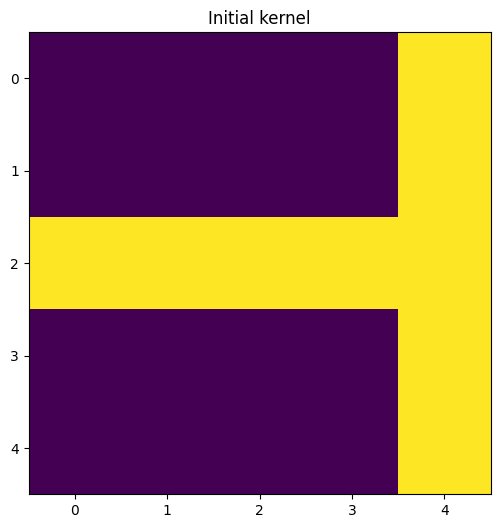

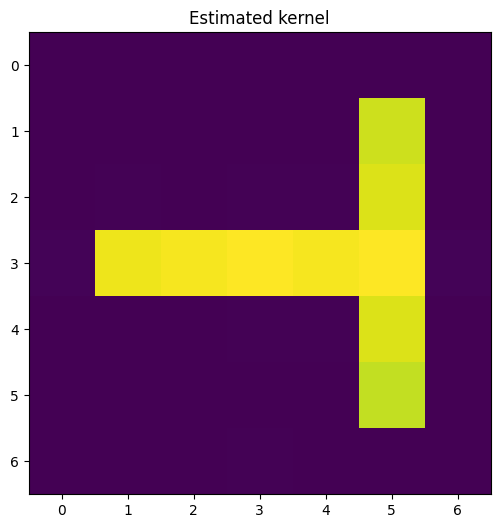

In [ ]:
image = io.imread(IMAGE_REF)

# Convert to grayscale for kernel estimation / ADMM (use OpenCV for proper luminance)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float64)
n, m = gray.shape
print('Using grayscale shape (n,m)=', (n, m))

# Build derivative kernels that match the actual image size
kernel_derivation_x = kernel_vers_grand(np.array([[0, 0, 0],[1, 0, -1],[0, 0, 0]]), n, m)
kernel_derivation_y = kernel_vers_grand(np.array([[0, 1, 0],[0, 0, 0],[0, -1, 0]]), n, m)

# Create blurred / noisy / denoised versions and convert to grayscale for the solver
initial_kernel = np.array([[0, 0, 0, 0, 1],
                        [0, 0, 0, 0, 1],
                        [1, 1, 1, 1, 1],
                        [0, 0, 0, 0, 1],
                        [0, 0, 0, 0, 1]])

kernel_base = initial_kernel / np.sum([np.sum(i) for i in initial_kernel])
B = np.array(cv2.filter2D(image, -1, cv2.flip(kernel_base, -1)))
noise = 20 * np.random.normal(0, 0.6, image.shape)
N = np.clip((image + noise).astype(np.int64), 0, 255).astype(np.uint8)
DN = denoise_colored_image(N)

# Compute gradients (these expect 2D inputs) and run a short ADMM test
gradient_blurred = gradient(B, True)
gradient_denoised = gradient(DN, True)
taille_noyau = 7

# Use a small number of iterations for a quick test; increase for full runs
kernel, energies, du = admm(gradient_blurred, gradient_denoised, lambd=0.2, seuil=1e-3, max_iter=10, taille_noyau=taille_noyau)
noyau = convert_large_kernel_to_real_kernel(kernel, taille_noyau)
plt.imshow(initial_kernel)
plt.title('Initial kernel')
plt.show()
plt.imshow(noyau)
plt.title('Estimated kernel')
plt.show()
## Save the estimated kernel image
io.imsave(DATA_DIR / 'kernel_estimation/estimated_kernel.png', (noyau / np.max(noyau) * 255).astype(np.uint8))
## Save the initial kernel image
io.imsave(DATA_DIR / 'kernel_estimation/initial_kernel.png', (initial_kernel * 255).astype(np.uint8))
## Save the energy values and du values in a csv
import pandas as pd
energy_df = pd.DataFrame({'Iteration': range(len(energies)), 'Energy': energies, 'Du': du})
energy_df.to_csv(DATA_DIR / 'kernel_estimation/energy_du_values.csv', index=False)

Iteration  0 en cours...
0.27616870490480977
0.0038545873779384297
0.0
19889.777503573074
10042.597067883551
0.0
20569.236999002653
10329.118767717267
0.0
20680.876521802158
10363.140423283723
Iteration  1 en cours...
0.2792968984622008
0.0033099913599415757
0.0
19894.71478829922
10034.074230743332
0.0
20525.992238260893
10310.67580036856
0.0
20615.736125016927
10342.421401775857
Iteration  2 en cours...
0.2814568582660482
0.0025524454393169166
0.0
19903.140253978963
10030.116340816396
0.0
20495.33967780487
10295.085506212712
0.0
20572.465944971587
10323.967208993352
[np.float64(22952694.763707306), np.float64(22804847.902965594), np.float64(18739907.95530813), np.float64(18634873.175643858), np.float64(16312497.029892117), np.float64(16244272.230663352)] [np.float64(0.27616870490480977), np.float64(0.0038545873779384297), np.float64(0.2792968984622008), np.float64(0.0033099913599415757), np.float64(0.2814568582660482), np.float64(0.0025524454393169166)] [np.float64(460424085.24578744)

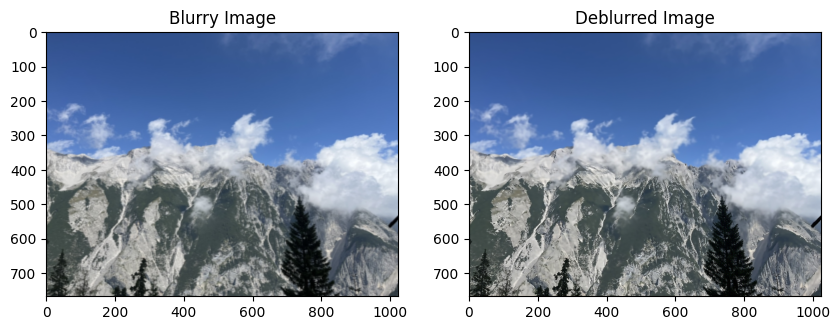

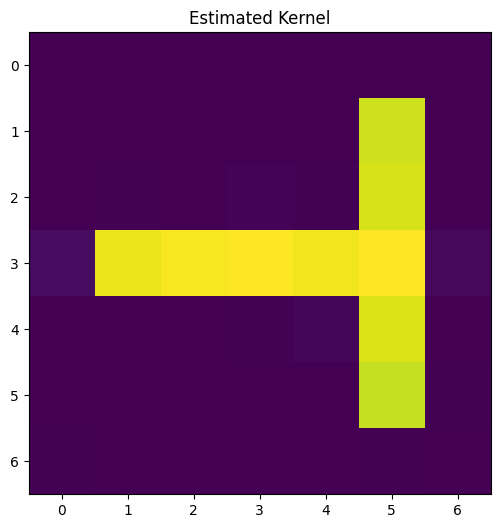

In [ ]:
taille_noyau = 7
algo_returns = whole_algo(B, N, taille_noyau=taille_noyau, iterations_whole=3, iterations_kernel=5, iterations_deblur=3)
image_result, kernel, kernel_energies, kernel_du_values, deblur_energies, deblur_du_values = algo_returns

## Save the energies and du values to two csv files
kernel_energies = [item for sublist in kernel_energies for item in sublist]
kernel_du_values = [item for sublist in kernel_du_values for item in sublist]
deblur_energies = [item for sublist in deblur_energies for item in sublist]
deblur_du_values = [item for sublist in deblur_du_values for item in sublist]
print(kernel_energies, kernel_du_values, deblur_energies, deblur_du_values)
kernel_energy_df = pd.DataFrame({'Iteration': range(len(kernel_energies)), 'Energy': kernel_energies, 'Du': kernel_du_values})
kernel_energy_df.to_csv(DATA_DIR / 'whole_algorithm/kernel_energy_du_values.csv', index=False)
deblur_energy_df = pd.DataFrame({'Iteration': range(len(deblur_energies)), 'Energy': deblur_energies, 'Du': deblur_du_values})
deblur_energy_df.to_csv(DATA_DIR / 'whole_algorithm/deblur_energy_du_values.csv', index=False)


io.imsave(DATA_DIR / 'whole_algorithm/initial_image.png', image.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm/blurry_image.png', B.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm/noisy_image.png', N.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm/denoised_image.png', DN.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm/deblurred_image.png', image_result.astype(np.uint8))

plt.subplot(1, 2, 1)
plt.imshow(B.astype(np.uint8))
plt.title('Blurry Image')
plt.subplot(1, 2, 2)
plt.imshow(image_result.astype(np.uint8))
plt.title('Deblurred Image')
plt.show()


kernel = convert_large_kernel_to_real_kernel(kernel, taille_noyau)

io.imsave(DATA_DIR / 'whole_algorithm/estimated_kernel.png', (kernel / np.max(kernel) * 255).astype(np.uint8))

plt.imshow(kernel)
plt.title('Estimated Kernel')
plt.show()


### Now with our own images

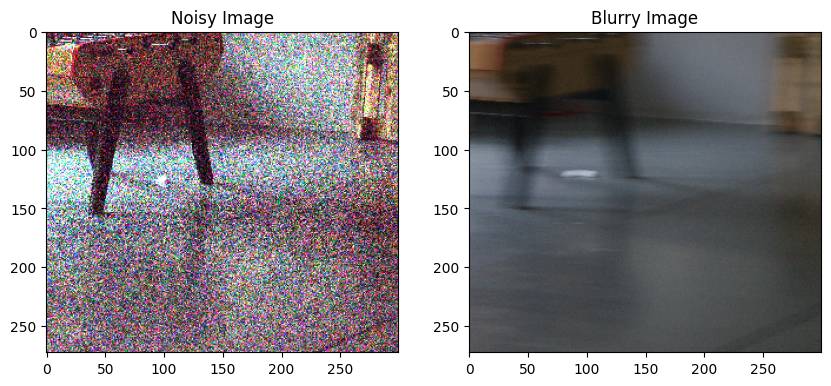

In [ ]:

noisy = cv2.imread(DATA_DIR / "home-made/image9.jpg")
blurry = cv2.imread(DATA_DIR / "home-made/image8.jpg")
h, w = noisy.shape[:2]

## Resize the images to be 1/3 of the original size for faster processing
ratio = 6
noisy = cv2.resize(noisy, (w//ratio, h//ratio))
blurry = cv2.resize(blurry, (w//ratio, h//ratio))

size = 300
offset = (200, 200)
## take only the middle square of size 300x300 offseted by offset
noisy = noisy[offset[1]:offset[1]+size, offset[0]:offset[0]+size]
blurry = blurry[offset[1]:offset[1]+size, offset[0]:offset[0]+size]

h, w = noisy.shape[:2]

## Multiply the noisy because it is underilluminated
noisy = np.clip(noisy.astype(np.float64) * 20., 0, 255).astype(np.uint8)

## convert colors from BGR to RGB for plotting
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)
blurry = cv2.cvtColor(blurry, cv2.COLOR_BGR2RGB)

## Show both images side by side
plt.subplot(1, 2, 1)
plt.imshow(noisy)
plt.title('Noisy Image')
plt.subplot(1, 2, 2)
plt.imshow(blurry)
plt.title('Blurry Image')
plt.show()


0.0746612753918637
0.003724447121297085
0.004060182531953709
0.0033161069364271894
0.002585656473998011
0.0020439252173298983
0.0016809602615299078
0.0014337971675233833
0.0012350367957741427
0.001077320166543946


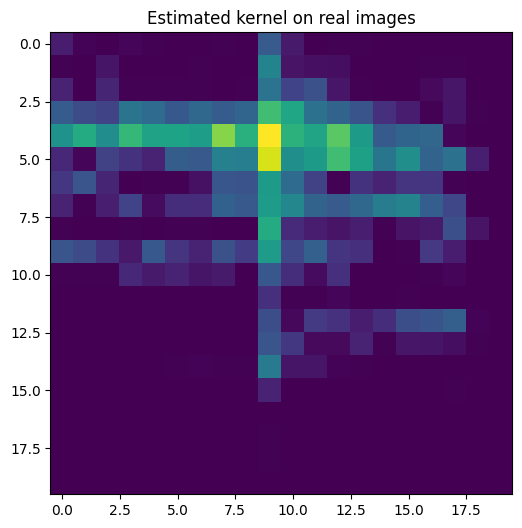

In [ ]:

kernel_derivation_x = kernel_vers_grand(np.array([[0, 0, 0],[1, 0, -1],[0, 0, 0]]), h, w)
kernel_derivation_y = kernel_vers_grand(np.array([[0, 1, 0],[0, 0, 0],[0, -1, 0]]), h, w)
gradient_blurred = gradient(blurry, True)
gradient_denoised = gradient(denoise_colored_image(noisy), True)
taille_noyau = 20

kernel, energies, du = admm(gradient_blurred, gradient_denoised, lambd=0.01, seuil=1e-3, max_iter=10, taille_noyau=taille_noyau)
noyau = convert_large_kernel_to_real_kernel(kernel, taille_noyau)
plt.imshow(noyau)
plt.title('Estimated kernel on real images')
plt.show()

Iteration  0 en cours...
0.08244484465622687
9.422256349865036e-08
0.0
27926.474708224494
12648.172890772583
6518.063977511472
4417.49358710062
3820.600023650978
3571.7023658245944
3378.9861780235824
3197.488837624297
3027.8415596621953
0.0
20096.097859829926
10316.059099795864
4779.389158913267
2435.109082410715
1611.2334963991082
1390.9119451533277
1327.6555917587366
1291.018920873225
1257.660675185525
0.0
23651.173006873036
11469.615483728827
5535.729256998255
3285.6570957827116
2621.492951110673
2423.029629080592
2311.3973976901966
2210.664320016882
2113.106213345856
Iteration  1 en cours...
0.07833709730884686
8.299566971396636e-08
0.0
22758.36418085628
11686.006612542347
5426.143245830982
2560.735303667291
1283.5613258209755
747.6535268362625
533.896835735422
441.394028305725
388.51991676017275
0.0
16530.546870903843
8988.233067292102
4094.4312648642463
1865.8545327200234
853.5634686958365
397.0903341311497
196.49737884882182
113.70319900125844
83.5441182041863
0.0
19351.29819827

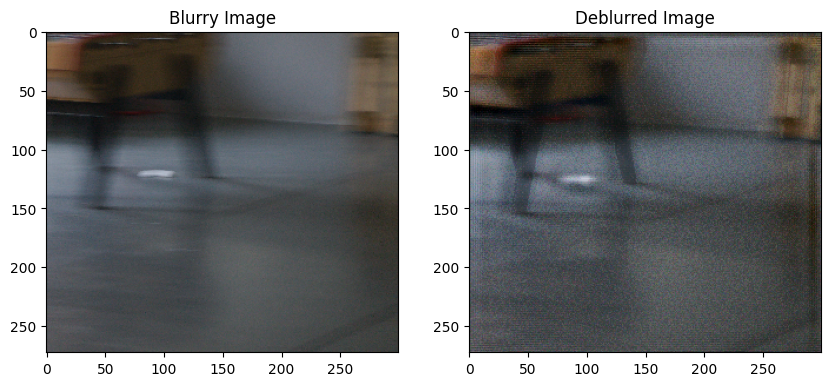

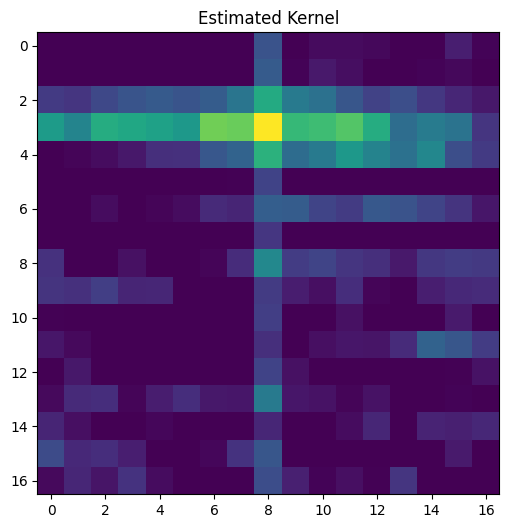

[np.float64(7003337.46553123), np.float64(7003338.02052345), np.float64(5503821.740936176), np.float64(5503822.259932493), np.float64(5230718.799357307), np.float64(5230720.867848563), np.float64(5059147.100019007), np.float64(5059148.14509868), np.float64(4962574.492469092), np.float64(4962632.280585126), np.float64(4818102.03730103), np.float64(4818103.267961955), np.float64(4740813.529549039), np.float64(4740815.012045023), np.float64(4700514.5495192595), np.float64(4700516.117524396), np.float64(4628014.907658944), np.float64(4628020.632966205), np.float64(4586481.939689378), np.float64(4585907.762703369)] [np.float64(0.08244484465622687), np.float64(9.422256349865036e-08), np.float64(0.07833709730884686), np.float64(8.299566971396636e-08), np.float64(0.08163901246122349), np.float64(1.525481334750592e-07), np.float64(0.08388988406276995), np.float64(4.5435467149118895e-07), np.float64(0.08585489876143644), np.float64(1.13422491203739e-05), np.float64(0.09004402395394709), np.float

In [ ]:

taille_noyau = 17

algo_returns = whole_algo(blurry, noisy, taille_noyau=taille_noyau, iterations_whole=10, iterations_kernel=5, iterations_deblur=10, lambd=0.3, beta=0.6)
image_result, kernel, kernel_energies, kernel_du_values, deblur_energies, deblur_du_values = algo_returns

plt.subplot(1, 2, 1)
plt.imshow(blurry.astype(np.uint8))
plt.title('Blurry Image')
plt.subplot(1, 2, 2)
plt.imshow(image_result.astype(np.uint8))
plt.title('Deblurred Image')
plt.show()


kernel = convert_large_kernel_to_real_kernel(kernel, taille_noyau)
plt.imshow(kernel)
plt.title('Estimated Kernel')
plt.show()



kernel_energies = [item for sublist in kernel_energies for item in sublist]
kernel_du_values = [item for sublist in kernel_du_values for item in sublist]
deblur_energies = [item for sublist in deblur_energies for item in sublist]
deblur_du_values = [item for sublist in deblur_du_values for item in sublist]
kernel_energy_df = pd.DataFrame({'Iteration': range(len(kernel_energies)), 'Energy': kernel_energies, 'Du': kernel_du_values})
kernel_energy_df.to_csv(DATA_DIR / 'whole_algorithm_2/kernel_energy_du_values.csv', index=False)
deblur_energy_df = pd.DataFrame({'Iteration': range(len(deblur_energies)), 'Energy': deblur_energies, 'Du': deblur_du_values})
deblur_energy_df.to_csv(DATA_DIR / 'whole_algorithm_2/deblur_energy_du_values.csv', index=False)

io.imsave(DATA_DIR / 'whole_algorithm_2/blurry_image.png', blurry.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm_2/noisy_image.png', noisy.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm_2/deblurred_image.png', image_result.astype(np.uint8))
io.imsave(DATA_DIR / 'whole_algorithm_2/estimated_kernel.png', (kernel / np.max(kernel) * 255).astype(np.uint8))